# Basic temperature model
A basic model that predicts the room temperature for a house over the next 30 hours

Variables in:
- Room temperature
- User setpoint temperature
- External temperature

Variables out:
- Room temperature

In [2]:
import os
from datetime import datetime
from glob import glob

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.dates import DayLocator, DateFormatter, HourLocator

## Preprocessing
### Load data

In [3]:
data_path = "data/PST_Data_20260220"
temperature_files = [f for f in glob(os.path.join(data_path, "*.csv")) if "Events" not in f]

In [16]:
houses_to_exclude = ['30097']

In [18]:
house_data = {}
for house_index in range(len(temperature_files)):
    house_id = temperature_files[house_index].split("/")[-1].split("_")[0]
    if house_id not in houses_to_exclude:
        # Don't include the above houses
        print('Loading data for house ID: ', house_id)
        house_df = pd.read_csv(temperature_files[house_index])
        print('Data quantity in house: ', len(house_df))
        # Store only variables needed for training
        df = pd.DataFrame({})
        # Convert time to datetime
        df['Datetime'] = [datetime.strptime(t, '%Y-%m-%d %H:%M') for t in house_df['Time (UTC)'].values]
        df['Room temperature'] = house_df['Room temperature (Zone 1) (°C)']
        df['User setpoint'] = house_df['Setpoint temperature (Zone 1) (°C)']
        df['External temperature'] = house_df['External temperature (°C)']

        house_data[house_id] = df

Loading data for house ID:  30436
Data quantity in house:  39745
Loading data for house ID:  29962
Data quantity in house:  39745
Loading data for house ID:  30568
Data quantity in house:  39745
Loading data for house ID:  30069
Data quantity in house:  39745
Loading data for house ID:  30715
Data quantity in house:  39745
Loading data for house ID:  28190
Data quantity in house:  37931
Loading data for house ID:  30668
Data quantity in house:  39745
Loading data for house ID:  30641
Data quantity in house:  39745


### Data cleaning
TBC

### Scaling data
Should we mormalise inputs to be between 0 and 1?

### Window data
Almost every house has 39745 data points (other than house 28190 which has 37931)


In [ ]:
# Create sequences and labels
def create_sequences(data, seq_length):
  xs, ys = [], []
  for i in range(len(data) - seq_length):
    x = data[i:i+seq_length] # Sequence of length `seq_length`
    y = data[i+seq_length] # Label is the next value
    xs.append(x)
    ys.append(y)
  return np.array(xs), np.array(ys)

SEQ_LENGTH = 7

In [ ]:
def create_sequences(df, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i+seq_length] # Sequence of length `seq_length`
        y = data[i+seq_length] # Label is the next value
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

# Model for a house

In [55]:
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import numpy as np

In [46]:
house_id = '28190'

# Extract data
house_df = house_data[house_id]

# Data cleaning - for now will just drop parts of dataframe which have NaN
house_df = house_df.dropna()
input_features = house_df[['Room temperature', 'User setpoint', 'External temperature']].values
target = house_df['Room temperature'].values

In [47]:
print(len(input_features))
print(len(target))

35581
35581


In [48]:
scaler = MinMaxScaler()
input_features = scaler.fit_transform(input_features)

In [49]:
# Split the data into training and testing sets
train_size = int(len(input_features) * 0.8)
train_input = input_features[:train_size]
test_input = input_features[train_size:]
train_target = target[:train_size]
test_target = target[train_size:]

In [54]:
def create_sequences(input_data, target_data, seq_length):
    inp_seq = []
    tgt_seq = []
    for i in range(len(input_data) - seq_length):
        inp_seq.append(input_data[i:i + seq_length])
        tgt_seq.append(target_data[i + seq_length])
    inp_seq = np.array(inp_seq)
    tgt_seq = np.array(tgt_seq)
    return torch.tensor(inp_seq, dtype=torch.float32), torch.tensor(tgt_seq, dtype=torch.float32)


seq_length = 10
train_inp_seq, train_tgt_seq = create_sequences(train_input, train_target, seq_length)
test_inp_seq, test_tgt_seq = create_sequences(test_input, test_target, seq_length)

In [56]:
class MultivariateLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        super(MultivariateLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])
        return out

input_size = train_inp_seq.shape[2]
hidden_size = 32
num_layers = 2
output_size = 1

model = MultivariateLSTM(input_size, hidden_size, num_layers, output_size)

In [57]:
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100
for epoch in range(num_epochs):
    outputs = model(train_inp_seq)
    optimizer.zero_grad()
    loss = criterion(outputs, train_tgt_seq.unsqueeze(1))
    loss.backward()
    optimizer.step()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [10/100], Loss: 290.5965
Epoch [20/100], Loss: 280.4844
Epoch [30/100], Loss: 255.2839
Epoch [40/100], Loss: 215.2283
Epoch [50/100], Loss: 188.5170
Epoch [60/100], Loss: 168.9191
Epoch [70/100], Loss: 154.7895
Epoch [80/100], Loss: 143.5719
Epoch [90/100], Loss: 133.8986
Epoch [100/100], Loss: 125.2271


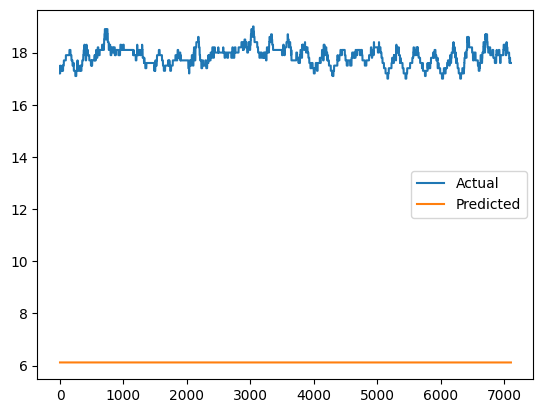

In [58]:
model.eval()
with torch.no_grad():
    test_predictions = model(test_inp_seq)
    test_predictions = test_predictions.numpy().flatten()

# Plot the results
plt.plot(test_target[seq_length:], label='Actual')
plt.plot(test_predictions, label='Predicted')
plt.legend()
plt.show()